# 09 — Tables de données : membres, tickers, panel annuel

**Objet.** Construire progressivement 4 fichiers CSV dans `tables/` :

| fichier | grain | lignes | contenu |
|---|---|---|---|
| `membres.csv` | 1 ligne = 1 membre | 372 | identité, activité, portefeuille, risque/perf, track record, comportement |
| `tickers.csv` | 1 ligne = 1 ticker | 4 618 | identité, flux Congrès, marché, croisement |
| `membres_annees.csv` | 1 ligne = (membre, année) | ~1 800 | activité et performance par année |
| `dictionnaire_colonnes.csv` | 1 ligne = 1 colonne | — | définition, source, type de chaque colonne |

**Principe.** Aucune stratégie ici : uniquement de la *donnée propre et comprise*. Chaque famille de
colonnes = une section : définitions mathématiques d'abord, calcul ensuite, validation à la fin.
Les CSV ne sont écrits qu'après la cellule de contrôles croisés (§12) : aucun fichier incohérent ne peut sortir.

## §0.1 Notations (utilisées dans tout le notebook)

**Ensembles et indices**

$$m \in \mathcal{M} \;(\text{membres, clé } \texttt{bioguide\_id}), \qquad
k \in \mathcal{K} \;(\text{tickers, clé } \texttt{ticker\_yahoo}), \qquad
j \;(\text{trade}), \qquad t \in \mathrm{cal}$$

- $\mathrm{cal}$ = calendrier de bourse maître (index des prix SPY, 2012-2026).
- Trade $j$ : $\big(m_j,\; k_j,\; d_j,\; \tau_j,\; A_j\big)$ avec $d_j \in \{\text{buy}, \text{sell}\}$,
  $\tau_j$ = date de **transaction** (`traded`), $A_j$ = montant midpoint (`size_usd`).
- Deux périmètres : $\mathcal{T}^{brut}$ = table canonique filtrée aux années 2013-2026 (**134 429** trades,
  372 membres, 4 618 tickers) ; $\mathcal{T} \subset \mathcal{T}^{brut}$ = trades dont le ticker a un prix
  exploitable (**118 029** trades, 3 289 tickers) — le périmètre du moteur 05b/07.

**Prix et portefeuille reconstruit (moteur 05b, entrée à $\tau_j$)**

$$P_k(t) = \text{prix ajusté, forward-fill sur } \mathrm{cal} \qquad\quad
n_k^m(t) = \text{parts FIFO détenues par } m \text{ (pas de short)}$$

$$V_m(t) = \sum_k n_k^m(t)\,P_k(t), \qquad
w_k^m(t) = \frac{n_k^m(t)\,P_k(t)}{V_m(t)}, \qquad
r_m(t) = \frac{\sum_k n_k^m(t{-}1)\,P_k(t)}{\sum_k n_k^m(t{-}1)\,P_k(t{-}1)} - 1$$

- $r_m$ est *time-weighted* (insensible aux apports), winsorisé à $\pm 50\,\%$/jour,
  restreint aux jours actifs ($V_m > 0$) ; $T_m$ = nombre de jours actifs ; $r_{SPY}(t)$ = rendement du SPY.
- $x_j$ = excès de rendement du trade $j$ (défini au §5bis).

**Exclusions assumées** : options/produits dérivés (absents des PTR collectés), montants exacts
(brackets STOCK Act $\Rightarrow$ midpoint = mesure censurée par intervalle), saisonnalité par membre
(traitée au niveau population dans le 07).

## §1 Moteur — recopié à l'identique des notebooks 05b/07/08

Les cellules marquées « COPIE EXACTE » reproduisent le moteur audité (05b via 07) sans modification :
c'est ce qui garantit que chaque nombre de ce notebook est identique à ceux déjà validés.

In [1]:
# === COPIE EXACTE 05b — cellule 2 (ne pas modifier : garantit l'équivalence) ===
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices_v2")

In [2]:
# === COPIE EXACTE 05b — cellule 3 (ne pas modifier : garantit l'équivalence) ===
# Table PROPRE canonique S1/S2 (source-primaire) -> noms alignés sur la mécanique du 05.
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
n0 = len(df)
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")

134464 -> 134429 trades  |  372 membres  |  4618 tickers


In [3]:
# === COPIE EXACTE 05b — cellule 5 (ne pas modifier : garantit l'équivalence) ===
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché

In [4]:
# === COPIE EXACTE 05b — cellule 7 (ne pas modifier : garantit l'équivalence) ===
# Charge les prix utiles, alignés sur le calendrier ; garde-fou anti-corruption Yahoo
# (cache complet : la cellule de téléchargement du 05b/07 est inutile ici — 0 réseau)
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))} - {"failed_v2"}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)
prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()
corrompus = [tk for tk in need if (len(prices[tk].dropna()) < 2
             or prices[tk].dropna().min() < 0.10
             or prices[tk].dropna().pct_change().abs().max() > 3.0)]   # <0,10$ ou saut >300%/j
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]
n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)} | sans prix : {len(missing)} | corrompus exclus : {len(corrompus)} | trades jetés : {n_drop}  => {len(df)} exploitables")

tickers avec prix : 3289 | sans prix : 1268 | corrompus exclus : 61 | trades jetés : 16400  => 118029 exploitables


In [5]:
# === COPIE EXACTE 05b — cellule 9 (ne pas modifier : garantit l'équivalence) ===
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marché)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

def member_shares(g):
    # g = trades d'un membre  ->  N (parts détenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

In [6]:
# === COPIE EXACTE 05b — cellule 14 (ne pas modifier : garantit l'équivalence) ===
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Σ n_i(t-1) P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Σ n_i(t-1) P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # winsorisation ±50 %/jour
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [7]:
# === COPIE EXACTE 05b — cellule 16 (ne pas modifier : garantit l'équivalence) ===
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


In [8]:
# === COPIE EXACTE 07 — cellule 18 (ne pas modifier : garantit l'équivalence) ===
# dfx = table canonique (37 col. avec owner_n/name_canon), MÊME périmètre que df
_raw = pd.read_csv(CLEAN, low_memory=False)
dfx = (_raw.drop(columns=["ticker"])
           .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                            "direction": "op", "transaction_date": "traded",
                            "amount_midpoint": "size_usd"}))
dfx["traded"] = pd.to_datetime(dfx["traded"], errors="coerce")
dfx["disclosure_date"] = pd.to_datetime(dfx["disclosure_date"], errors="coerce")
dfx = dfx[dfx["traded"].dt.year.between(2013, 2026)]
dfx = dfx[dfx["ticker"].isin(set(need))].reset_index(drop=True)
assert len(dfx) == len(df), (len(dfx), len(df))

# owner normalisé (mapping OWNER17 du 05b) + nom canonique par bioguide
OWNER = {"Spouse":"conjoint","SP":"conjoint","SELF":"élu","Self":"élu",
         "JT":"joint","Joint Tenancy":"joint","Joint":"joint",
         "Dependent Child":"enfant","DC":"enfant","Child":"enfant"}
dfx["owner_n"] = dfx["owner"].map(OWNER)
_name_canon = dfx.groupby("bioguide_id")["name"].agg(lambda s: s.mode().iloc[0])
dfx["name_canon"] = dfx["bioguide_id"].map(_name_canon)
print(f"dfx : {len(dfx)} trades × {dfx.shape[1]} colonnes | owner_n couvert : {dfx.owner_n.notna().mean():.0%} | "
      f"{dfx.bioguide_id.nunique()} membres")

dfx : 118029 trades × 37 colonnes | owner_n couvert : 100% | 359 membres


In [9]:
# dfb = version 𝒯^brut de dfx (AVANT le filtre ticker-avec-prix) — mêmes renommages, mêmes années
dfb = (_raw.drop(columns=["ticker"])
           .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                            "direction": "op", "transaction_date": "traded",
                            "amount_midpoint": "size_usd"}))
dfb["traded"] = pd.to_datetime(dfb["traded"], errors="coerce")
_hors_annees = int((~dfb["traded"].dt.year.between(2013, 2026)).sum())
dfb = dfb[dfb["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
dfb["owner_n"] = dfb["owner"].map(OWNER)
print(f"𝒯^brut : {len(dfb)} trades ({_hors_annees} hors 2013-2026 écartés de la table canonique {len(_raw)}) | "
      f"{dfb.bioguide_id.nunique()} membres | {dfb.ticker.nunique()} tickers")

𝒯^brut : 134429 trades (35 hors 2013-2026 écartés de la table canonique 134464) | 372 membres | 4618 tickers


In [10]:
# === COPIE EXACTE 05b — cellule 23 (ne pas modifier : garantit l'équivalence) ===
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

def alpha_beta(r):
    # Régression r = alpha + beta*r_spy + eps -> beta, alpha annualisé, appraisal, t_appr
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, appraisal=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)      # pente, ordonnée
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = (alpha / se * np.sqrt(252)) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, appraisal=appr,
                t_appr=appr * np.sqrt(len(d) / 252))

In [11]:
# === COPIE EXACTE 07 — cellules 43/44/52 (fonctions seules) + 03 — cellule 17 (sortino) ===
from collections import deque
LAST_DAY = cal.max()

def fifo_holding(g):                                   # 07 c.43
    closed, opened = [], []          # (durée_j, parts) fermés ; (durée_censurée_j, parts) ouverts
    for tk, gt in g.groupby("ticker"):
        lots = deque()
        for _, row in gt.sort_values("traded").iterrows():        # MÊME tri que member_shares
            dd, p = eff_price(tk, row["traded"])
            if dd is None: continue
            q = row["size_usd"] / p
            if row["op"] == "buy":
                lots.append([dd, q])
            else:
                held = sum(l[1] for l in lots); qv = min(q, held); take_tot = qv
                while take_tot > 1e-12 and lots:
                    tau_b, parts = lots[0]; take = min(parts, take_tot)
                    closed.append(((dd - tau_b).days, take)); take_tot -= take
                    if parts - take <= 1e-12: lots.popleft()
                    else: lots[0][1] = parts - take
        for tau_b, parts in lots:
            if parts > 1e-9:
                opened.append(((LAST_DAY - tau_b).days, parts))
    return closed, opened

def km_weighted(closed, opened):                       # 07 c.44 — Kaplan-Meier pondéré parts
    ev = pd.DataFrame({"t": closed.duree, "w": closed.parts, "event": 1})
    ce = pd.DataFrame({"t": opened.duree, "w": opened.parts, "event": 0})
    alld = pd.concat([ev, ce]).sort_values("t")
    times = np.sort(ev["t"].unique())
    S = 1.0
    xs, ys = [0], [1.0]
    for t in times:
        at_risk = alld.loc[alld.t >= t, "w"].sum()
        d = ev.loc[ev.t == t, "w"].sum()
        if at_risk > 0:
            S *= (1 - d / at_risk)
        xs.append(t); ys.append(S)
    return np.array(xs), np.array(ys)

def exces_spy(bid):                                    # 07 c.52
    r = wf_ret[bid]; nav = (1+r).cumprod(); cagr = nav.iloc[-1]**(252/len(r))-1
    rs = r_spy.reindex(r.index).fillna(0.0); navs = (1+rs).cumprod(); cagrs = navs.iloc[-1]**(252/len(rs))-1
    return cagr - cagrs

def sortino(r):                                        # 03 c.17
    d = r.dropna(); dn = d[d < 0].std()
    return d.mean() / dn * np.sqrt(252) if dn > 0 else np.nan

In [12]:
# === COPIE EXACTE 08 — §2.3 (matrice comité→GICS gelée + parsing des codes THOMAS) ===
SECTEURS = ["Information Technology", "Financials", "Health Care", "Industrials",
            "Consumer Discretionary", "Communication Services", "Consumer Staples",
            "Energy", "Materials", "Real Estate", "Utilities"]

COMITE_GICS = {   # chaque ligne justifiée par le champ jurisdiction officiel (cf. notebook 08 §2.3)
    "HSAG": {"Consumer Staples", "Materials"},          "SSAF": {"Consumer Staples", "Materials"},
    "HSAS": {"Industrials"},  "SSAS": {"Industrials"},  "HLIG": {"Industrials"},
    "HSHM": {"Industrials", "Information Technology"},
    "HSBA": {"Financials", "Real Estate"},              "SSBK": {"Financials", "Real Estate"},
    "HSIF": {"Energy", "Utilities", "Health Care", "Communication Services"},
    "HSII": {"Energy", "Materials", "Utilities"},       "SSEG": {"Energy", "Utilities", "Materials"},
    "SSEV": {"Utilities", "Materials", "Industrials"},  "HSPW": {"Industrials", "Utilities"},
    "SSCM": {"Industrials", "Communication Services", "Information Technology"},
    "HSWM": {"Health Care", "Financials"},              "SSFI": {"Health Care", "Financials"},
    "HSSY": {"Information Technology"},                 "SSHR": {"Health Care"},
    "HSVR": {"Health Care"},
    # transverses → ∅ (les inclure viderait « aligné » de son sens)
    "HSAP": set(), "SSAP": set(), "HSGO": set(), "SSGA": set(), "HSRU": set(), "HSHA": set(),
    "HSJU": set(), "SSJU": set(), "HSFA": set(), "SSFR": set(), "HSSM": set(), "HSED": set(),
}

import re
def codes_racine(s):
    if not isinstance(s, str):
        return frozenset()
    return frozenset(t.strip()[:4] for t in s.split(";") if re.fullmatch(r"[A-Z]{4}\d*", t.strip()))

### §1.1 Validation — équivalence avec les notebooks 05b/07

Compteurs et valeurs **gelés depuis les sorties exécutées** du 07 : périmètre
$|\mathcal{T}| = 118\,029$, $|\mathcal{K}_{prix}| = 3\,289$, $|\{m : r_m \text{ existe}\}| = 266$,
éligibles $= 223$ ; contrôles individuels sur les 2 plus gros traders (Khanna, McCaul).

In [13]:
# (i) compteurs gelés (sorties 07 c.7/c.11/c.13/c.20)
assert len(df) == 118029 and len(dfx) == 118029, len(df)
assert len(need) == 3289, len(need)
assert len(wf_ret) == 266, len(wf_ret)
assert len(dfb) == 134429 and dfb.bioguide_id.nunique() == 372, (len(dfb), dfb.bioguide_id.nunique())

# (ii) éligibilité (conventions 05b c.20 : n_trades ≥ 10 et T_m ≥ 126)
_nt = df.groupby("bioguide_id").size()
_nd = pd.Series({b: len(r) for b, r in wf_ret.items()})
_eligible = ((_nt.reindex(_nd.index) >= 10) & (_nd >= 126))
assert int(_eligible.sum()) == 223, int(_eligible.sum())

# (iii) valeurs individuelles gelées (sortie 07 c.37) : Khanna puis McCaul
for _bid, _n, _ntk, _sh in [("K000389", 32684, 975, 0.87), ("M001157", 16028, 582, 0.61)]:
    assert int(_nt[_bid]) == _n, (_bid, int(_nt[_bid]))
    assert dfx.loc[dfx.bioguide_id == _bid, "ticker"].nunique() == _ntk
    assert round(stats(wf_ret[_bid])["sharpe"], 2) == _sh, (_bid, stats(wf_ret[_bid])["sharpe"])
print("§1.1 OK — moteur identique au 05b/07 (118 029 / 3 289 / 266 / 223 ; Khanna et McCaul reproduits)")

§1.1 OK — moteur identique au 05b/07 (118 029 / 3 289 / 266 / 223 ; Khanna et McCaul reproduits)


## §2 `membres` — famille A : identité et mandat

Squelette : $\mathcal{M}$ = les 372 `bioguide_id` de $\mathcal{T}^{brut}$. Définitions
(les agrégats sont pris sur $\mathcal{T}^{brut}$, l'identité ne dépend pas de la couverture prix) :

$$\texttt{name} = \operatorname{mode}(\text{variantes du nom}), \qquad
\texttt{party},\ \texttt{chamber} = \operatorname{mode}, \qquad
\texttt{state} = \texttt{state\_district}[{:}2]$$

$$\texttt{comites}(m) = \bigcup_j \operatorname{codes}(\texttt{committee\_membership}_j), \qquad
\texttt{secteurs\_juridiction}(m) = \bigcup_{c \in \texttt{comites}(m)} \mathrm{COMITE\_GICS}[c]$$

`leader` et `leader_postes` viennent du fichier vérifié `leadership_2014_2026.csv` (12 postes de parti) ;
`years_in_office` de `table_congres_2014_2026.csv`.

In [14]:
def _mode(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

_ab = dfb.groupby("bioguide_id")
M = pd.DataFrame(index=pd.Index(sorted(dfb.bioguide_id.unique()), name="bioguide_id"))
M["name"] = _ab["name"].agg(_mode)
M.loc[M.index.isin(_name_canon.index), "name"] = _name_canon        # nom canonique 𝒯 prioritaire
M["party"] = _ab["party"].agg(_mode)
M["chamber"] = _ab["chamber"].agg(_mode)
M["state"] = _ab["state_district"].agg(_mode).astype(str).str[:2]
M["congress_first"] = _ab["congress"].min()
M["congress_last"] = _ab["congress"].max()

_tc = pd.read_csv(os.path.join(BASE, "table_congres_2014_2026.csv"), low_memory=False)
M["years_in_office"] = _tc.dropna(subset=["bioguide_id"]).groupby("bioguide_id")["years_in_office"].max()

_lead = pd.read_csv(os.path.join(BASE, "leadership_2014_2026.csv"))
M["leader"] = M.index.isin(set(_lead["bioguide_id"]))
_postes = _lead.groupby("bioguide_id")["poste"].agg(lambda s: "|".join(sorted(set(s))))
M["leader_postes"] = M.index.map(_postes)

_codes_m = _ab["committee_membership"].agg(lambda s: frozenset().union(*s.map(codes_racine)))
M["comites"] = _codes_m.map(lambda cs: "|".join(sorted(cs)))
M["comite_cle"] = _ab["committees_key_flag"].agg(lambda s: bool(pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any()))
_juri = _codes_m.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
M["secteurs_juridiction"] = _juri.map(lambda ss: "|".join(sorted(ss)))
M["n_secteurs_juridiction"] = _juri.map(len)
print(f"M : {len(M)} membres × {M.shape[1]} colonnes")
M.head(3)

M : 372 membres × 13 colonnes


,name,party,chamber,state,congress_first,congress_last,years_in_office,leader,leader_postes,comites,comite_cle,secteurs_juridiction,n_secteurs_juridiction
bioguide_id,,,,,,,,,,,,,
A000055,Robert B. Aderholt,Republican,house,AL,117,119,28.0,False,NaN,HSAP,False,,0
A000148,Jake Auchincloss,Democrat,house,MA,118,119,5.0,False,NaN,HSIF|HSPW,False,Communication Services|Energy|Health Care|Indu...,5
A000210,Robert E. Andrews,Democrat,house,NJ,113,113,23.0,False,NaN,,False,,0


### §2.1 Validation

In [15]:
assert len(M) == 372 and M.index.is_unique
assert M["name"].notna().all() and (M["state"].str.len() == 2).all()
assert M["leader"].sum() == _lead["bioguide_id"].nunique() - len(set(_lead["bioguide_id"]) - set(M.index)), "leaders hors périmètre ?"
_n_lead_dans_T = len(set(_lead["bioguide_id"]) & set(wf_ret))
assert _n_lead_dans_T == 8, _n_lead_dans_T          # sortie gelée 07 c.37 : « 8 leaders »
assert (M["n_secteurs_juridiction"] <= 11).all()
print(f"§2.1 OK — 372 lignes, clé unique | {int(M.leader.sum())} leaders au total, {_n_lead_dans_T} parmi les reconstruits")

§2.1 OK — 372 lignes, clé unique | 10 leaders au total, 8 parmi les reconstruits


## §3 `membres` — famille B : activité de déclaration, temps de présence

Sur $\mathcal{T}$ (auditables contre `beh` du 07), sauf $\texttt{n\_trades\_brut}$ sur $\mathcal{T}^{brut}$ :

$$\texttt{buy\_share} = \frac{\#\{j : d_j = \text{buy}\}}{\#\{j\}}, \qquad
\texttt{notional\_x} = \sum_{j \,:\, d_j = x} A_j, \qquad
\texttt{pct\_1re\_fourchette} = \mathbb{P}\big(A_j \le 8\,000{,}5\big)$$

$$\texttt{lag\_med} = \operatorname{med}_j(\texttt{lag\_days}_j), \qquad
\texttt{part\_late} = \mathbb{P}(\texttt{lag} > 45\,\text{j}), \qquad
\texttt{part\_very\_late} = \mathbb{P}(\texttt{lag} > 365\,\text{j})$$

$$\texttt{duree\_activite\_j} = \max_j \tau_j - \min_j \tau_j, \qquad
\texttt{actif\_12m} = \mathbb{1}\big\{\max_j \tau_j \ge \max(\mathrm{cal}) - 365\,\text{j}\big\}$$

In [16]:
_ax = dfx.groupby("bioguide_id")
M["n_trades_brut"] = _ab.size()
M["n_trades"] = _ax.size()
M["n_buy"] = _ax["op"].agg(lambda s: int((s == "buy").sum()))
M["n_sell"] = _ax["op"].agg(lambda s: int((s == "sell").sum()))
M["buy_share"] = _ax["op"].agg(lambda s: (s == "buy").mean())
M["notional_total"] = _ax["size_usd"].sum()
M["notional_buy"] = dfx[dfx.op == "buy"].groupby("bioguide_id")["size_usd"].sum()
M["notional_sell"] = dfx[dfx.op == "sell"].groupby("bioguide_id")["size_usd"].sum()
M["taille_med"] = _ax["size_usd"].median()
M["pct_1re_fourchette"] = _ax["size_usd"].agg(lambda s: (s <= 8000.5).mean())
M["lag_med"] = _ax["lag_days"].median()
M["part_late"] = _ax["flag_late_filing"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).mean())
M["part_very_late"] = _ax["flag_very_late_filing"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).mean())
M["owner_dom"] = _ax["owner_n"].agg(_mode)
M["part_conjoint"] = _ax["owner_n"].agg(lambda s: (s == "conjoint").mean())
M["part_self"] = _ax["owner_n"].agg(lambda s: (s == "élu").mean())
M["first_trade"] = _ax["traded"].min().dt.date
M["last_trade"] = _ax["traded"].max().dt.date
M["duree_activite_j"] = (_ax["traded"].max() - _ax["traded"].min()).dt.days
M["n_annees_actives"] = _ax["traded"].agg(lambda s: s.dt.year.nunique())
M["actif_12m"] = _ax["traded"].max() >= (cal.max() - pd.Timedelta(days=365))
print(f"M : {M.shape[1]} colonnes après famille B")

M : 34 colonnes après famille B


### §3.1 Validation

In [17]:
assert int(M["n_trades_brut"].sum()) == 134429
assert int(M["n_trades"].fillna(0).sum()) == 118029
assert int((M["n_buy"].fillna(0) + M["n_sell"].fillna(0)).sum()) == 118029
# Khanna : valeurs gelées de beh (07 c.37)
assert round(float(M.loc["K000389", "buy_share"]), 2) == 0.57
assert round(float(M.loc["K000389", "part_conjoint"]), 2) == 0.65
assert pd.Timestamp(M["first_trade"].dropna().min()) == df["traded"].min()
assert M.loc[M["n_trades"].notna(), "lag_med"].notna().all()
print(f"§3.1 OK — Σ brut 134 429, Σ 𝒯 118 029 | Khanna buy_share 0,57 / conjoint 0,65 | "
      f"membres actifs sur 12 derniers mois : {int(M.actif_12m.sum())}")

§3.1 OK — Σ brut 134 429, Σ 𝒯 118 029 | Khanna buy_share 0,57 / conjoint 0,65 | membres actifs sur 12 derniers mois : 103


## §4 `membres` — famille C (1/3) : la passe portefeuille unique

Une **seule** boucle sur les 266 membres reconstruits : $N = n^m$ (matrice parts) est calculée
une fois, on en tire toutes les statistiques de portefeuille, puis $N$ est jetée (mémoire).
Formules identiques à `concentration()` et `turnover()` du 07 (c.39/c.41) :

$$\mathrm{HHI}_m = \overline{\Big(\sum_k w_k^m(t)^2\Big)}_{t\,:\,V_m>0}, \qquad
N^{e\!f\!f}_m = \frac{1}{\mathrm{HHI}_m}, \qquad
\texttt{top1}_m = \overline{\max_k w_k^m(t)}$$

$$\texttt{turnover}_m = \frac{\sum_j A_j}{2\,\bar V_m} \cdot \frac{252}{T_m}, \qquad
\bar V_m = \overline{V_m(t)}_{V_m > 0}$$

Les épisodes FIFO (achat $\to$ vente appariée, `fifo_holding` 07 c.43) sont stockés **par membre**
pour le §6.

In [18]:
PORT, EPIS = {}, {}
for b in wf_ret:
    g = df[df.bioguide_id == b]
    N = member_shares(g)
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    NP = N * P
    V = NP.sum(axis=1); act = V > 0
    W = NP.div(V, axis=0)[act]
    hhi = float((W ** 2).sum(axis=1).mean())
    vbar = float(V[act].mean())
    PORT[b] = dict(
        hhi=hhi, n_eff=1 / hhi if hhi > 0 else np.nan,
        top1=float(W.max(axis=1).mean()),
        n_pos_moy=float((N[act] > 0).sum(axis=1).mean()),
        valeur_moy=vbar, valeur_fin=float(V.iloc[-1]),
        turnover=(g["size_usd"].sum() / (2 * vbar) * 252 / int(act.sum()))
                 if (vbar > 0 and act.sum() >= 2) else np.nan)
    EPIS[b] = fifo_holding(g)
    del N, P, NP, V, W
_port = pd.DataFrame(PORT).T
for c in _port.columns:
    M[c] = _port[c]
M["reconstruit"] = M.index.isin(wf_ret)
M["n_days"] = pd.Series({b: len(r) for b, r in wf_ret.items()})
M["n_tickers"] = dfx.groupby("bioguide_id")["ticker"].nunique()
M["n_episodes_fermes"] = pd.Series({b: len(c) for b, (c, o) in EPIS.items()})
print(f"passe unique : {len(PORT)} membres | colonnes portefeuille jointes")

passe unique : 266 membres | colonnes portefeuille jointes


### §4.1 Validation — mêmes valeurs que les fonctions d'origine, mêmes compteurs pooled

In [19]:
# (i) la passe unique reproduit concentration()/turnover() du 07 sur 3 membres (identité numérique)
def concentration(bid):                                 # === COPIE EXACTE 07 c.39 (contrôle) ===
    g = df[df.bioguide_id == bid]; N = member_shares(g)
    if N is None: return None
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    V = (N*P).sum(axis=1); act = V > 0
    if act.sum() == 0: return None
    W = (N*P).div(V, axis=0)[act]
    hhi = (W**2).sum(axis=1).mean()
    return dict(hhi=hhi, n_eff=1/hhi if hhi>0 else np.nan, top1=W.max(axis=1).mean(),
                n_pos_moy=(N[act]>0).sum(axis=1).mean())
for _b in ["K000389", "M001157", "P000197"]:
    _ref = concentration(_b)
    for _k in ("hhi", "n_eff", "top1", "n_pos_moy"):
        assert abs(_ref[_k] - M.loc[_b, _k]) < 1e-9, (_b, _k)

# (ii) épisodes ré-agrégés = compteurs gelés du 07 c.43
_cl = pd.DataFrame([e for c, o in EPIS.values() for e in c], columns=["duree", "parts"])
_op = pd.DataFrame([e for c, o in EPIS.values() for e in o], columns=["duree", "parts"])
assert (len(_cl), len(_op)) == (61963, 28944), (len(_cl), len(_op))
_pct_open = _op.parts.sum() / (_cl.parts.sum() + _op.parts.sum())
assert round(_pct_open, 2) == 0.44, _pct_open
# (iii) médiane de survie KM pooled ≈ 910 j (sortie gelée 07 c.44)
_kx, _ky = km_weighted(_cl, _op)
_med_km_pool = _kx[np.searchsorted(-_ky, -0.5)]
assert abs(_med_km_pool - 910) <= 5, _med_km_pool
print(f"§4.1 OK — concentration/turnover identiques | épisodes 61 963/28 944, encore détenu 44 % | KM pooled {_med_km_pool:.0f} j")

§4.1 OK — concentration/turnover identiques | épisodes 61 963/28 944, encore détenu 44 % | KM pooled 910 j


## §5 `membres` — famille D : risque et performance (série time-weighted $r_m$)

$$\texttt{cagr}_m = NAV_m(T_m)^{252/T_m} - 1, \qquad
\texttt{vol}_m = \sigma(r_m)\sqrt{252}, \qquad
\texttt{sharpe}_m = \frac{\bar r_m}{\sigma(r_m)}\sqrt{252}, \qquad
\texttt{sortino}_m = \frac{\bar r_m}{\sigma(r_m^-)}\sqrt{252}$$

$$\texttt{ir}_m = \frac{\overline{r_m - r_{SPY}}}{\sigma(r_m - r_{SPY})}\sqrt{252}, \qquad
t_{IR} = \mathrm{IR}\sqrt{T_m/252}, \qquad
r_m = \alpha + \beta\, r_{SPY} + \varepsilon
\;\Rightarrow\; \texttt{appraisal}_m = \frac{\alpha}{\sigma_\varepsilon}\sqrt{252}$$

La `vol` d'un portefeuille à 1 titre est la vol du titre : c'est une valeur **vraie**, à lire avec
`n_eff` et `eligible` ($n \ge 10$ trades et $T_m \ge 126$ j).

In [20]:
_rows = {}
for b, r in wf_ret.items():
    st = stats(r); ab = alpha_beta(r)
    T = len(r)
    _rows[b] = dict(cagr=st["cagr"], vol=st["vol"], sharpe=st["sharpe"], maxdd=st["maxdd"],
                    sortino=sortino(r),
                    t_sharpe=st["sharpe"] * np.sqrt(T / 252) if np.isfinite(st["sharpe"]) else np.nan,
                    ir=info_ratio(r), beta=ab["beta"], alpha_ann=ab["alpha_ann"],
                    appraisal=ab["appraisal"], t_appr=ab["t_appr"],
                    exces_cagr_spy=exces_spy(b))
_perf = pd.DataFrame(_rows).T
_perf["t_ir"] = _perf["ir"] * np.sqrt(M["n_days"].reindex(_perf.index) / 252)
for c in _perf.columns:
    M[c] = _perf[c]
M["eligible"] = (M["n_trades"].fillna(0) >= 10) & (M["n_days"].fillna(0) >= 126)
print(f"famille D : {len(_perf)} membres | éligibles : {int(M.eligible.sum())}")

famille D : 266 membres | éligibles : 223


### §5.1 Validation

In [21]:
assert int(M["eligible"].sum()) == 223
assert round(float(M.loc["K000389", "sharpe"]), 2) == 0.87            # beh gelé (07 c.37)
assert round(float(M.loc["M001157", "sharpe"]), 2) == 0.61
# cohérence interne : sharpe = cagr-like sign, |beta| raisonnable pour les éligibles
_e = M[M.eligible]
assert _e["vol"].between(0, 3).all() and _e["beta"].dropna().between(-2, 5).all()
print(f"§5.1 OK — 223 éligibles | Khanna 0,87 / McCaul 0,61 | vol médiane éligibles {_e.vol.median():.1%}")

§5.1 OK — 223 éligibles | Khanna 0,87 / McCaul 0,61 | vol médiane éligibles 20.4%


## §5bis `membres` — famille F : track record par trade (mécanique du 06, critères du 03)

Pour chaque **achat** $j$ : entrée au close de $J{+}1(\tau_j)$, sortie au close de
$t^s_j = \min\big(J{+}1(\text{première vente du même } (m, k) \text{ après } \tau_j),\; J{+}1(\tau_j) + 252\big)$,
**brut de coûts** (c'est le talent du membre, pas la stratégie d'un copieur) :

$$x_j = \frac{P_{k_j}(t^s_j)}{P_{k_j}(J{+}1(\tau_j))} - \frac{SPY(t^s_j)}{SPY(J{+}1(\tau_j))}
\qquad\quad
x^{raw}_j = \frac{P_{k_j}(t^s_j)}{P_{k_j}(J{+}1(\tau_j))} - 1$$

$$\texttt{hit\_rate} = \mathbb{P}(x_j > 0), \quad
\texttt{profit\_factor} = \min\Big(\frac{\sum x_j^+}{|\sum x_j^-|},\, 10\Big), \quad
t_x = \frac{\bar x}{\sigma_x / \sqrt{n}}
\qquad (\text{critères } c_1, c_5, c_9 \text{ du notebook 03})$$

In [22]:
# appariement première-vente (=== mécanique 06 c.14, sur les dates de TRANSACTION ===)
_b = dfx[dfx.op == "buy"][["bioguide_id", "ticker", "traded"]].sort_values("traded").reset_index()
_s = (dfx[dfx.op == "sell"][["bioguide_id", "ticker", "traded"]].dropna()
      .sort_values("traded").rename(columns={"traded": "sortie_vente"}))
_paires = pd.merge_asof(_b, _s, left_on="traded", right_on="sortie_vente",
                        by=["bioguide_id", "ticker"], direction="forward", allow_exact_matches=False)
_b["sortie_vente"] = _paires["sortie_vente"].values

# excès vectorisé (=== mécanique 06 c.15, SANS le -2c ; entrée traded J+1, plafond 252 j ===)
px = pd.DataFrame(prices)                       # déjà ffillés sur cal (socle 05b)
PXV = px.to_numpy(); SPYV = spy.to_numpy()
COL = {tk: i for i, tk in enumerate(px.columns)}
# garde anti-prix périmé : dernier jour de VRAIE cotation par ticker (fichier brut, pas le ffill)
_last_true = {}
for tk in need:
    _d = pd.read_csv(os.path.join(PRICES, tk + ".csv"), usecols=["Date"])["Date"]
    _last_true[tk] = cal.searchsorted(pd.Timestamp(_d.iloc[-1]), side="right") - 1
_LAST = np.array([_last_true[tk] for tk in px.columns])

HOLD_MAX = 252
i0 = cal.searchsorted(pd.DatetimeIndex(_b["traded"]), side="right")
i_v = cal.searchsorted(pd.DatetimeIndex(pd.Series(_b["sortie_vente"]).fillna(cal[-1])), side="right")
i1 = np.where(_b["sortie_vente"].isna(), i0 + HOLD_MAX, np.minimum(i_v, i0 + HOLD_MAX))
i1 = np.minimum(np.maximum(i1, i0 + 1), len(cal) - 1)
cols = np.array([COL.get(t, -1) for t in _b["ticker"]])
ok = (cols >= 0) & (i0 < len(cal) - 1) & (i0 <= _LAST[np.maximum(cols, 0)])   # entrée sur une vraie cote
x = np.full(len(_b), np.nan); xr = np.full(len(_b), np.nan)
r_, c0, c1 = cols[ok], i0[ok], np.asarray(i1)[ok]
p0, p1 = PXV[c0, r_], PXV[c1, r_]
b0, b1 = SPYV[c0], SPYV[c1]
valid = ~(np.isnan(p0) | np.isnan(p1)) & (p0 > 0) & (b0 > 0)
_res = np.full(int(ok.sum()), np.nan); _resr = np.full(int(ok.sum()), np.nan)
_res[valid] = (p1[valid] / p0[valid] - 1) - (b1[valid] / b0[valid] - 1)
_resr[valid] = p1[valid] / p0[valid] - 1
x[ok] = _res; xr[ok] = _resr
_b["x"], _b["x_raw"] = x, xr
_bt = _b.dropna(subset=["x"])
print(f"{len(_bt):,} achats évalués / {len(_b):,} | excès moyen brut {_bt.x.mean():+.2%} | médiane {_bt.x.median():+.2%}")

58,926 achats évalués / 59,984 | excès moyen brut -0.23% | médiane -1.62%


In [23]:
_g = _bt.groupby("bioguide_id")["x"]
M["n_trades_evalues"] = _g.size()
M["hit_rate"] = _g.agg(lambda a: (a > 0).mean())                                   # c1 du 03
M["exces_moyen_trade"] = _g.mean()                                                 # c3
M["exces_med_trade"] = _g.median()                                                 # c4
M["ret_brut_moyen_trade"] = _bt.groupby("bioguide_id")["x_raw"].mean()             # c2
M["profit_factor"] = _g.agg(lambda a: min(a[a > 0].sum() / abs(a[a <= 0].sum()), 10.0)
                            if (a <= 0).any() and a[a <= 0].sum() != 0 else 10.0)  # c5
M["t_exces_trade"] = _g.agg(lambda a: a.mean() / (a.std(ddof=1) / np.sqrt(len(a)) + 1e-12)
                            if len(a) > 1 else np.nan)                             # c9
print(f"famille F : {int(M.n_trades_evalues.notna().sum())} membres avec track record")

famille F : 267 membres avec track record


### §5bis.1 Validation — un trade recalculé à la main + bornes

In [24]:
# (i) un achat NVDA de Pelosi, recalculé pas à pas (style 06 §2)
DEMO_BID = df.loc[df["name"] == "Nancy Pelosi", "bioguide_id"].iloc[0]
_ex = _bt[(_bt.bioguide_id == DEMO_BID) & (_bt.ticker == "NVDA")].iloc[0]
_i0 = cal.searchsorted(_ex["traded"], side="right")
_iv = cal.searchsorted(_ex["sortie_vente"], side="right") if pd.notna(_ex["sortie_vente"]) else _i0 + HOLD_MAX
_i1 = min(max(min(_iv, _i0 + HOLD_MAX), _i0 + 1), len(cal) - 1)
_pn = prices["NVDA"]
_x_main = (_pn.iloc[_i1] / _pn.iloc[_i0] - 1) - (spy.iloc[_i1] / spy.iloc[_i0] - 1)
assert abs(_x_main - _ex["x"]) < 1e-12, (_x_main, _ex["x"])
# (ii) bornes et cohérences
assert (M["n_trades_evalues"].fillna(0) <= M["n_buy"].fillna(0)).all()
assert M["hit_rate"].dropna().between(0, 1).all()
assert M["profit_factor"].dropna().between(0, 10).all()
# (iii) ordre de grandeur vs 06 §4 (copy-all à la disclosure, NET de 40 bps : -0,42 %) :
#      ici entrée à traded et BRUT -> attendu au-dessus, même échelle de % (pas d'égalité attendue)
assert abs(_bt.x.mean()) < 0.05
print(f"§5bis.1 OK — trade main = vectorisé ({_x_main:+.2%}) | moyenne pooled {_bt.x.mean():+.2%} "
      f"(06 §4 net disclosure : -0,42 % — écart = brut vs net, traded vs disclosure)")

§5bis.1 OK — trade main = vectorisé (-4.15%) | moyenne pooled -0.23% (06 §4 net disclosure : -0,42 % — écart = brut vs net, traded vs disclosure)


## §6 `membres` — famille C (2/3) : durées de détention par membre

Sur les épisodes FIFO du §4 (achat $\to$ vente appariée ; épisodes encore ouverts = **censurés**) :

$$\texttt{duree\_med\_fermee}_m = \operatorname{med}_w(\text{durées closes}), \qquad
\texttt{duree\_km\_med}_m = \inf\{t : \hat S_m(t) \le 0{,}5\}$$

$$\texttt{part\_ouverte}_m = \frac{\sum_{ouverts} q}{\sum_{clos} q + \sum_{ouverts} q}, \qquad
\texttt{n\_allers\_retours\_30j}_m = \#\{\text{épisodes clos} < 30 \text{ j}\}$$

$\hat S_m$ = estimateur de Kaplan-Meier pondéré par les parts (`km_weighted` 07 c.44).
`duree_km_med` = NaN quand $> 50\,\%$ des parts sont encore détenues (buy-and-holder) : c'est une
information, à lire avec `part_ouverte`.

In [25]:
def _med_ponderee(d, w):
    # médiane pondérée : premier d (trié) dont le cumul des poids atteint 50 %
    o = np.argsort(d); d, w = np.asarray(d)[o], np.asarray(w)[o]
    cw = np.cumsum(w)
    return float(d[np.searchsorted(cw, 0.5 * cw[-1])])

_rows = {}
for b, (c, o) in EPIS.items():
    cl = pd.DataFrame(c, columns=["duree", "parts"]); op = pd.DataFrame(o, columns=["duree", "parts"])
    row = dict(part_ouverte=op.parts.sum() / (cl.parts.sum() + op.parts.sum())
               if (cl.parts.sum() + op.parts.sum()) > 0 else np.nan,
               n_allers_retours_30j=int((cl.duree < 30).sum()))
    row["duree_med_fermee"] = _med_ponderee(cl.duree.values, cl.parts.values) if len(cl) else np.nan
    if len(cl):
        kx, ky = km_weighted(cl, op)
        row["duree_km_med"] = float(kx[np.searchsorted(-ky, -0.5)]) if ky.min() <= 0.5 else np.nan
    else:
        row["duree_km_med"] = np.nan
    _rows[b] = row
_dur = pd.DataFrame(_rows).T
for c in _dur.columns:
    M[c] = _dur[c]
print(f"durées : {len(_dur)} membres | KM médiane atteinte pour {int(M.duree_km_med.notna().sum())} membres")

durées : 266 membres | KM médiane atteinte pour 125 membres


### §6.1 Validation — mini-exemple synthétique + cohérence pooled

In [26]:
# (i) exemple synthétique : 2 épisodes clos (10 j, poids 1) et (100 j, poids 1), 0 ouvert
#     -> med pondérée = 10 (cumul 50 % atteint au 1er) ; KM : S(10)=0,5 -> médiane = 10
_clt = pd.DataFrame({"duree": [10, 100], "parts": [1.0, 1.0]})
_opt = pd.DataFrame({"duree": [], "parts": []})
assert _med_ponderee(_clt.duree.values, _clt.parts.values) == 10
_kxt, _kyt = km_weighted(_clt, _opt)
assert float(_kxt[np.searchsorted(-_kyt, -0.5)]) == 10.0
# (ii) part_ouverte agrégée (pondérée parts) = 44 % (gelé 07 c.43)
_tot_cl = sum(pd.DataFrame(c, columns=["duree", "parts"]).parts.sum() for c, o in EPIS.values())
_tot_op = sum(pd.DataFrame(o, columns=["duree", "parts"]).parts.sum() for c, o in EPIS.values())
assert round(_tot_op / (_tot_cl + _tot_op), 2) == 0.44
print("§6.1 OK — synthétique exact | part encore détenue pooled 44 %")

§6.1 OK — synthétique exact | part encore détenue pooled 44 %


## §7 `membres` — famille C (3/3) : actions principales et secteurs

Par **notional d'achat** (auditables sans reconstruction ; la mesure « poids quotidien » reste `top1`) :

$$\texttt{topK\_part}_m = \frac{\sum_{j\,:\,k_j = \text{topK},\, d_j = \text{buy}} A_j}{\texttt{notional\_buy}_m},
\qquad
\texttt{sect\_s}_m = \frac{\sum_{j\,:\,\mathrm{GICS}(k_j) = s,\, d_j = \text{buy}} A_j}{\texttt{notional\_buy}_m},
\qquad \sum_s \texttt{sect\_s}_m = 1$$

In [27]:
_buys = dfx[dfx.op == "buy"]
_mk = _buys.groupby(["bioguide_id", "ticker"])["size_usd"].sum().sort_values(ascending=False)
_top = (_mk.groupby(level=0).head(10).reset_index()
        .sort_values(["bioguide_id", "size_usd"], ascending=[True, False]))
_tl = _top.groupby("bioguide_id").agg(tks=("ticker", list), usd=("size_usd", list))
for i in (1, 2, 3):
    M[f"top{i}_ticker"] = _tl["tks"].map(lambda l: l[i - 1] if len(l) >= i else np.nan)
    M[f"top{i}_part"] = _tl["usd"].map(lambda l: l[i - 1] if len(l) >= i else np.nan) / M["notional_buy"]
M["top10_tickers"] = _tl["tks"].map("|".join)

SECT_COLS = {"Information Technology": "sect_info_tech", "Financials": "sect_financials",
             "Health Care": "sect_health", "Industrials": "sect_industrials",
             "Consumer Discretionary": "sect_conso_disc", "Communication Services": "sect_comm",
             "Consumer Staples": "sect_conso_stap", "Energy": "sect_energy",
             "Materials": "sect_materials", "Real Estate": "sect_real_estate",
             "Utilities": "sect_utilities"}
_sec = (_buys.assign(sg=_buys["sector_gics"].map(SECT_COLS).fillna("sect_nc"))
        .pivot_table(index="bioguide_id", columns="sg", values="size_usd", aggfunc="sum", fill_value=0.0))
for c in list(SECT_COLS.values()) + ["sect_nc"]:
    if c not in _sec.columns:
        _sec[c] = 0.0
_sec = _sec.div(_sec.sum(axis=1), axis=0)
for c in list(SECT_COLS.values()) + ["sect_nc"]:
    M[c] = _sec[c]
M["sect_dom"] = _buys.groupby("bioguide_id")["sector_gics"].agg(_mode)
_sd = _sec[list(SECT_COLS.values()) + ["sect_nc"]].max(axis=1)
M["part_sect_dom"] = _sd
print(f"top tickers + 12 parts sectorielles calculés pour {int(M.top1_ticker.notna().sum())} membres acheteurs")

top tickers + 12 parts sectorielles calculés pour 268 membres acheteurs


### §7.1 Validation

In [28]:
_sc = list(SECT_COLS.values()) + ["sect_nc"]
_has_buy = M["notional_buy"].fillna(0) > 0
_sums = M.loc[_has_buy, _sc].sum(axis=1)
assert (abs(_sums - 1) < 1e-9).all(), "les 12 parts sectorielles doivent sommer à 1"
assert M.loc[DEMO_BID, "top1_ticker"] == "AAPL"                    # fait gelé 07 §5.1 (Pelosi)
assert (M.loc[_has_buy, "top1_part"] >= M.loc[_has_buy, "top2_part"].fillna(0)).all()
print(f"§7.1 OK — Σ parts = 1 | top1 Pelosi = AAPL ({M.loc[DEMO_BID, 'top1_part']:.0%} de ses achats)")

§7.1 OK — Σ parts = 1 | top1 Pelosi = AAPL (16% de ses achats)


## §8 `membres` — famille E : comportement

$$\texttt{part\_ci\_achats}_m = \mathbb{P}_j\big(\mathrm{GICS}(k_j) \in \mathcal{J}(\texttt{comites}_j)
\;\big|\; d_j = \text{buy}\big) \qquad (\text{alignement comité} \times \text{secteur, matrice du 08})$$

$$\texttt{part\_trades\_repetes}_m = \mathbb{P}_j\big(\exists\, j' : k_{j'} = k_j,\ \tau_{j'} < \tau_j\big), \qquad
\texttt{part\_coachat}_m = \mathbb{P}_j\big(\#\{m' \text{ acheteurs de } k_j \text{ le même mois}\} \ge 3
\;\big|\; d_j = \text{buy}\big)$$

In [29]:
# flag ci au niveau trade (=== logique 08 §2.3, committee_membership du TRADE = point-in-time ===)
_codes_tr = dfx["committee_membership"].map(codes_racine)
_juri_tr = _codes_tr.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
dfx["ci"] = [s in sm for s, sm in zip(dfx["sector_gics"], _juri_tr)]
M["part_ci_achats"] = dfx[dfx.op == "buy"].groupby("bioguide_id")["ci"].mean()

# répétition : trade sur un ticker déjà tradé avant par le même membre
_o = dfx.sort_values("traded")
dfx["repete"] = _o.groupby(["bioguide_id", "ticker"]).cumcount().reindex(dfx.index) > 0
M["part_trades_repetes"] = dfx.groupby("bioguide_id")["repete"].mean()

# co-achat : (ticker, mois) avec >= 3 acheteurs distincts (convention 07 §7)
_bm = dfx[dfx.op == "buy"].copy()
_bm["ym"] = _bm["traded"].dt.to_period("M")
_co = _bm.groupby(["ym", "ticker"])["bioguide_id"].transform("nunique")
_bm["coachat3"] = _co >= 3
M["part_coachat"] = _bm.groupby("bioguide_id")["coachat3"].mean()
print(f"famille E : part_ci moyenne (achats, nb) = {dfx.loc[dfx.op == 'buy', 'ci'].mean():.1%}")

famille E : part_ci moyenne (achats, nb) = 16.4%


### §8.1 Validation — le chiffre du 08 est reproduit **sur son périmètre**

Le 08 §2.3 calculait 17,0 % (nb) / 15,2 % ($) sur SON flux : table canonique **dédupliquée
`natural_key_hash` + actions seulement** (toutes années, sans filtre prix). On le reproduit ici à
l'identique, puis on affiche la valeur sur notre périmètre $\mathcal{T}$ (actions + ETF couverts prix).

In [30]:
# reproduction EXACTE du périmètre 08 : dédup natural_key_hash + asset_class == stock
_fl = _raw.drop_duplicates(subset=["natural_key_hash"], keep="first")
_fl = _fl[_fl["asset_class"] == "stock"].copy()
_cd = _fl["committee_membership"].map(codes_racine)
_ju = _cd.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
_fl["ci"] = [s in sm for s, sm in zip(_fl["sector_gics"], _ju)]
_ci_nb_08 = _fl.loc[_fl["direction"] == "buy", "ci"].mean()
_ci_usd_08 = _fl.loc[_fl["direction"] == "buy"].groupby("ci")["amount_midpoint"].sum()
_ci_usd_part_08 = _ci_usd_08.get(True, 0) / _ci_usd_08.sum()
assert round(_ci_nb_08, 3) == 0.170, _ci_nb_08          # sortie gelée 08 §2.3 : 17,0 %
assert round(_ci_usd_part_08, 3) == 0.152, _ci_usd_part_08   # 15,2 % en $
for c in ("part_ci_achats", "part_trades_repetes", "part_coachat"):
    assert M[c].dropna().between(0, 1).all(), c
_ci_T = dfx.loc[dfx.op == "buy", "ci"].mean()
print(f"§8.1 OK — périmètre 08 reproduit : {_ci_nb_08:.1%} (nb) / {_ci_usd_part_08:.1%} ($) | "
      f"sur 𝒯 (tables de ce notebook) : {_ci_T:.1%}")

§8.1 OK — périmètre 08 reproduit : 17.0% (nb) / 15.2% ($) | sur 𝒯 (tables de ce notebook) : 16.4%


## §9 `tickers` — familles A (identité) et B (flux Congrès)

$\mathcal{K}$ = les 4 618 tickers de $\mathcal{T}^{brut}$. Identité par $\operatorname{mode}$ sur les trades ;
flux sur $\mathcal{T}$ (sauf $\texttt{n\_trades\_brut}$) :

$$\texttt{notional\_net}_k = \sum_{j : k_j = k,\, d_j = \text{buy}} A_j - \sum_{j : k_j = k,\, d_j = \text{sell}} A_j,
\qquad
\texttt{part\_dem}_k = \frac{\sum_{j\,\text{buy},\ \text{Democrat}} A_j}{\sum_{j\,\text{buy}} A_j}$$

$$\texttt{coachat\_max}_k = \max_{\text{mois}} \#\{m : m \text{ achète } k \text{ ce mois}\}, \qquad
\texttt{n\_mois\_actifs}_k = \#\{(\text{année},\text{mois}) : \exists\, j\}$$

In [31]:
_tb = dfb.groupby("ticker")
K = pd.DataFrame(index=pd.Index(sorted(dfb.ticker.dropna().unique()), name="ticker"))
K["description"] = _tb["asset_description"].agg(_mode).astype(str).str[:80]
K["asset_class"] = _tb["asset_class"].agg(_mode)
K["is_broad_etf"] = _tb["is_broad_etf"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())
K["sector_gics"] = _tb["sector_gics"].agg(_mode)
K["etf_proxy"] = _tb["etf_proxy"].agg(_mode)
K["is_delisted"] = _tb["is_delisted"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())
K["delist_type"] = _tb["delist_type"].agg(_mode)
K["flag_price_caution"] = _tb["flag_price_caution"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())

_tx = dfx.groupby("ticker")
K["n_trades_brut"] = _tb.size()
K["n_trades"] = _tx.size()
K["n_buy"] = _tx["op"].agg(lambda s: int((s == "buy").sum()))
K["n_sell"] = _tx["op"].agg(lambda s: int((s == "sell").sum()))
K["notional_buy"] = dfx[dfx.op == "buy"].groupby("ticker")["size_usd"].sum()
K["notional_sell"] = dfx[dfx.op == "sell"].groupby("ticker")["size_usd"].sum()
K["notional_net"] = K["notional_buy"].fillna(0) - K["notional_sell"].fillna(0)
K["n_membres"] = _tx["bioguide_id"].nunique()
K["n_membres_buy"] = dfx[dfx.op == "buy"].groupby("ticker")["bioguide_id"].nunique()
K["n_membres_sell"] = dfx[dfx.op == "sell"].groupby("ticker")["bioguide_id"].nunique()
_dem = dfx[(dfx.op == "buy") & (dfx.party == "Democrat")].groupby("ticker")["size_usd"].sum()
K["part_dem"] = (_dem / K["notional_buy"]).where(K["notional_buy"].notna())
K["part_senate"] = _tx["chamber"].agg(lambda s: (s == "senate").mean())
K["part_conjoint"] = _tx["owner_n"].agg(lambda s: (s == "conjoint").mean())
K["part_ci_achats"] = dfx[dfx.op == "buy"].groupby("ticker")["ci"].mean()
K["first_trade"] = _tx["traded"].min().dt.date
K["last_trade"] = _tx["traded"].max().dt.date
K["n_mois_actifs"] = _tx["traded"].agg(lambda s: s.dt.to_period("M").nunique())
K["coachat_max"] = _bm.groupby(["ticker", "ym"])["bioguide_id"].nunique().groupby(level=0).max()
_tm = dfx.groupby(["ticker", "bioguide_id"])["size_usd"].sum().sort_values(ascending=False)
_tm3 = (_tm.groupby(level=0).head(3).reset_index()
        .sort_values(["ticker", "size_usd"], ascending=[True, False]))
K["top_membres"] = _tm3.groupby("ticker")["bioguide_id"].agg("|".join)
print(f"K : {len(K)} tickers × {K.shape[1]} colonnes")

K : 4618 tickers × 27 colonnes


### §9.1 Validation

In [32]:
assert len(K) == 4618 and K.index.is_unique, len(K)
assert int(K["n_trades_brut"].sum()) == 134429
assert int(K["n_trades"].fillna(0).sum()) == 118029
assert K["part_dem"].dropna().between(0, 1).all() and K["part_senate"].dropna().between(0, 1).all()
assert int(K["n_trades"].notna().sum()) == 3289          # tickers de 𝒯 = ceux couverts prix
print("§9.1 OK — 4 618 tickers, sommes exactes, 3 289 dans 𝒯")

§9.1 OK — 4 618 tickers, sommes exactes, 3 289 dans 𝒯


## §10 `tickers` — familles C (marché) et D (croisement)

**Marché** — sur la série de prix **brute** (jours réellement cotés, PAS la version forward-fill du
moteur : le ffill fabriquerait des rendements nuls et une vol biaisée vers 0 pour les délistés) :

$$\texttt{vol\_ann}_k = \sigma\big(\Delta \log P_k\big)\sqrt{252}, \qquad
\texttt{beta\_spy}_k = \frac{\operatorname{cov}(r_k, r_{SPY})}{\operatorname{var}(r_{SPY})}
\;\;(\ge 126 \text{ obs communes}), \qquad
\texttt{adv\_med}_k = \operatorname{med}_t\big(P^{raw}_k(t)\, \mathrm{Vol}_k(t)\big)$$

**Croisement** — event-study descriptif sur les **achats** (entrée $J{+}1(\tau_j)$, brut vs SPY) :

$$\texttt{exces\_H}_k = \overline{\Big[\tfrac{P_k(J{+}1(\tau_j)+H)}{P_k(J{+}1(\tau_j))}
- \tfrac{SPY(J{+}1(\tau_j)+H)}{SPY(J{+}1(\tau_j))}\Big]}_{j\,:\,k_j = k,\ d_j = \text{buy}},
\qquad H \in \{21, 63\}$$

In [33]:
VOLDIR = os.path.join(BASE, "cache", "volume_v1")
_mkt = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index().dropna())
    lr = np.log(s).diff().dropna()
    row = dict(px_first=s.index[0].date(), px_last=s.index[-1].date(), px_n_obs=len(s),
               vol_ann=float(lr.std() * np.sqrt(252)) if len(lr) > 20 else np.nan,
               ret_total=float(s.iloc[-1] / s.iloc[0] - 1),
               cagr_fenetre=float((s.iloc[-1] / s.iloc[0]) ** (252 / max(len(s), 1)) - 1) if len(s) > 20 else np.nan,
               maxdd=float((s / s.cummax() - 1).min()))
    _rk = s.pct_change().dropna()
    _pair = pd.concat([_rk.rename("y"), r_spy.reindex(_rk.index).rename("x")], axis=1).dropna()
    row["beta_spy"] = float(np.polyfit(_pair["x"], _pair["y"], 1)[0]) if len(_pair) >= 126 else np.nan
    _vf = os.path.join(VOLDIR, tk + ".csv")
    if os.path.exists(_vf):
        _v = pd.read_csv(_vf)
        row["adv_med"] = float((_v["close_raw"] * _v["volume"]).median())
    else:
        row["adv_med"] = np.nan
    _mkt[tk] = row
_mkt = pd.DataFrame(_mkt).T
K["px_couvert"] = K.index.isin(need)
for c in _mkt.columns:
    K[c] = _mkt[c]
print(f"marché : {len(_mkt)} tickers | ADV disponible : {int(K.adv_med.notna().sum())}")

marché : 3289 tickers | ADV disponible : 3247


In [34]:
# event-study 21/63 j sur les achats (mêmes tableaux vectorisés que §5bis)
for H, nom in [(21, "exces_21j_moy"), (63, "exces_63j_moy")]:
    iH = i0 + H
    okH = (cols >= 0) & (iH < len(cal)) & (i0 <= _LAST[np.maximum(cols, 0)])
    xH = np.full(len(_b), np.nan)
    rH, c0H, c1H = cols[okH], i0[okH], iH[okH]
    p0H, p1H = PXV[c0H, rH], PXV[c1H, rH]
    b0H, b1H = SPYV[c0H], SPYV[c1H]
    vH = ~(np.isnan(p0H) | np.isnan(p1H)) & (p0H > 0) & (b0H > 0)
    _r = np.full(int(okH.sum()), np.nan)
    _r[vH] = (p1H[vH] / p0H[vH] - 1) - (b1H[vH] / b0H[vH] - 1)
    xH[okH] = _r
    _b[nom] = xH
_ge = _b.dropna(subset=["exces_21j_moy"]).groupby("ticker")
K["exces_21j_moy"] = _ge["exces_21j_moy"].mean()
K["exces_63j_moy"] = _b.dropna(subset=["exces_63j_moy"]).groupby("ticker")["exces_63j_moy"].mean()
K["n_achats_evalues"] = _ge.size()
print(f"event-study : {int(K.n_achats_evalues.notna().sum())} tickers avec ≥1 achat évalué")

event-study : 2609 tickers avec ≥1 achat évalué


### §10.1 Validation

In [35]:
assert abs(K.loc["SPY", "beta_spy"] - 1) < 1e-6                       # SPY sur lui-même
assert 0.10 < K.loc["SPY", "vol_ann"] < 0.30
# délistés : une bonne part des séries brutes s'arrête avant la fin du calendrier
# (pas toutes : certains « faillis » cotent encore en OTC chez Yahoo, ex. BBBY)
_dl = K[K.is_delisted & K.px_couvert]
_stoppees = pd.to_datetime(_dl["px_last"]) < cal.max() - pd.Timedelta(days=5)
assert len(_dl) and _stoppees.any(), "aucun délisté à série arrêtée ?"
_ex_stop = _stoppees[_stoppees].index[0]
assert (K["n_achats_evalues"].fillna(0) <= K["n_buy"].fillna(0)).all()
assert K["vol_ann"].dropna().between(0, 5).all()
print(f"§10.1 OK — beta(SPY)=1, vol(SPY)={K.loc['SPY','vol_ann']:.0%} | délistés à série arrêtée : "
      f"{_stoppees.mean():.0%} de {len(_dl)} (ex. {_ex_stop}, dernier prix {K.loc[_ex_stop, 'px_last']})")

§10.1 OK — beta(SPY)=1, vol(SPY)=17% | délistés à série arrêtée : 30% de 10 (ex. CA, dernier prix 2026-05-26)


## §11 `membres_annees` — panel (membre, année civile)

Activité depuis $\mathcal{T}$ ; performance depuis la tranche annuelle de $r_m$
(NaN si $< 40$ jours actifs dans l'année — seuil anti-bruit gelé) :

$$\texttt{ret\_annee}_{m,Y} = \prod_{t \in Y}(1 + r_m(t)) - 1, \qquad
\texttt{exces\_spy\_annee}_{m,Y} = \texttt{ret\_annee}_{m,Y} - \Big[\prod_{t \in Y}(1 + r_{SPY}(t)) - 1\Big]
\;\;(\text{mêmes jours})$$

In [36]:
_pa = dfx.assign(annee=dfx["traded"].dt.year).groupby(["bioguide_id", "annee"])
PAN = pd.DataFrame({
    "n_trades": _pa.size(),
    "n_buy": _pa["op"].agg(lambda s: int((s == "buy").sum())),
    "buy_share": _pa["op"].agg(lambda s: (s == "buy").mean()),
    "notional": _pa["size_usd"].sum(),
    "n_tickers": _pa["ticker"].nunique(),
    "sect_dom": _pa["sector_gics"].agg(_mode),
})
_rowsy = {}
for b, r in wf_ret.items():
    for Y, ry in r.groupby(r.index.year):
        rs = r_spy.reindex(ry.index).fillna(0.0)
        _rowsy[(b, Y)] = dict(
            n_days=len(ry),
            vol=float(ry.std() * np.sqrt(252)) if len(ry) >= 40 else np.nan,
            sharpe=float(ry.mean() / ry.std() * np.sqrt(252)) if (len(ry) >= 40 and ry.std() > 0) else np.nan,
            ret_annee=float((1 + ry).prod() - 1) if len(ry) >= 40 else np.nan,
            exces_spy_annee=float((1 + ry).prod() - (1 + rs).prod()) if len(ry) >= 40 else np.nan)
_pf = pd.DataFrame(_rowsy).T
_pf.index = pd.MultiIndex.from_tuples(_pf.index, names=["bioguide_id", "annee"])
PAN = PAN.join(_pf, how="outer")
PAN.index.names = ["bioguide_id", "annee"]
print(f"panel : {len(PAN)} lignes (membre, année) | avec perf annuelle : {int(PAN.ret_annee.notna().sum())}")

panel : 2628 lignes (membre, année) | avec perf annuelle : 2398


### §11.1 Validation

In [37]:
assert int(PAN["n_trades"].fillna(0).sum()) == 118029
_pel24 = float(PAN.loc[(DEMO_BID, 2024), "ret_annee"])
assert abs(_pel24 - 0.385) < 0.003, _pel24                     # fait gelé 07 §6 : Pelosi 2024 = +38,5 %
assert PAN.index.is_unique
print(f"§11.1 OK — Σ trades 118 029 | Pelosi 2024 = {_pel24:+.1%} (= le +38,5 % du 07)")

§11.1 OK — Σ trades 118 029 | Pelosi 2024 = +38.5% (= le +38,5 % du 07)


## §12 Contrôles croisés globaux (aucun CSV n'est écrit si cette cellule échoue)

In [38]:
# 1. sommes de trades identiques entre les deux tables et le périmètre
assert int(M["n_trades"].fillna(0).sum()) == int(K["n_trades"].fillna(0).sum()) == 118029
assert int(M["n_trades_brut"].sum()) == int(K["n_trades_brut"].sum()) == 134429
# 2. notionals au centime
assert abs(M["notional_buy"].fillna(0).sum() - K["notional_buy"].fillna(0).sum()) < 0.01
assert abs(M["notional_sell"].fillna(0).sum() - K["notional_sell"].fillna(0).sum()) < 0.01
# 3. bipartite : Σ_k n_membres = # paires distinctes = Σ_m n_tickers
_paires_mk = dfx.groupby(["bioguide_id", "ticker"]).ngroups
assert int(K["n_membres"].fillna(0).sum()) == _paires_mk == int(M["n_tickers"].fillna(0).sum())
# 4. bornes temporelles cohérentes
assert M["first_trade"].dropna().min() == K["first_trade"].dropna().min()
assert M["last_trade"].dropna().max() == K["last_trade"].dropna().max()
# 5. compteurs population
assert len(M) == 372 and int(M["n_trades"].notna().sum()) == 359
assert int(M["reconstruit"].sum()) == 266 and int(M["eligible"].sum()) == 223
assert len(K) == 4618 and int(K["px_couvert"].sum()) == 3289
# 6. part_ci pooled identique vu des deux tables (pondération par le nombre d'achats)
#    et égale à la valeur pooled 𝒯 (le 17,0 % du 08 vit sur SON périmètre — reproduit au §8.1)
_ci_m = (M["part_ci_achats"] * M["n_buy"]).sum() / M["n_buy"].sum()
_ci_k = (K["part_ci_achats"] * K["n_buy"]).sum() / K["n_buy"].sum()
_ci_pool = dfx.loc[dfx.op == "buy", "ci"].mean()
assert abs(_ci_m - _ci_k) < 1e-12 and abs(_ci_m - _ci_pool) < 1e-12
# 7. épisodes FIFO (déjà §4.1) : 61 963 / 28 944 / 44 % — re-déclaré ici pour la trace
assert (len(_cl), len(_op)) == (61963, 28944)
# 8. cohérences internes
assert int((M["n_buy"].fillna(0) + M["n_sell"].fillna(0)).sum()) == 118029
assert not M["name"].astype(str).str.contains(r"\|").any()
assert not pd.Index(K.index.astype(str)).str.contains(r"\|").any()
print("§12 OK — les 8 contrôles croisés passent : les tables sont cohérentes entre elles")

§12 OK — les 8 contrôles croisés passent : les tables sont cohérentes entre elles


## §13 Écriture des CSV + dictionnaire des colonnes

Le dictionnaire est LA carte de lecture : une ligne par colonne (table, famille, définition, source,
type). Un `assert` garantit qu'il couvre exactement les colonnes réellement écrites.

In [39]:
TABLES = os.path.join(BASE, "tables")
os.makedirs(TABLES, exist_ok=True)

D = []   # (table, famille, colonne, définition, source, type)
def _d(table, fam, col, definition, source, typ):
    D.append(dict(table=table, famille=fam, colonne=col, definition=definition, source=source, type=typ))

# ---- membres : A identité ----
for c, dfn, src, ty in [
    ("name", "mode des variantes de nom (canonique 𝒯 prioritaire)", "dfx name_canon / dfb", "str"),
    ("party", "mode sur les trades", "dfb", "str"),
    ("chamber", "mode sur les trades (un House→Senate a un mode arbitraire)", "dfb", "str"),
    ("state", "state_district[:2]", "dfb", "str"),
    ("congress_first", "min(congress)", "dfb", "int"),
    ("congress_last", "max(congress)", "dfb", "int"),
    ("years_in_office", "max years_in_office", "table_congres_2014_2026.csv", "float"),
    ("leader", "bioguide ∈ leadership_2014_2026.csv (12 postes de parti)", "leadership CSV", "bool"),
    ("leader_postes", "postes occupés, séparés par |", "leadership CSV", "str"),
    ("comites", "∪ codes THOMAS racine (4 lettres), séparés par |", "committee_membership", "str"),
    ("comite_cle", "∃ trade avec committees_key_flag", "dfb", "bool"),
    ("secteurs_juridiction", "∪ COMITE_GICS[comites], séparés par |", "matrice 08 §2.3", "str"),
    ("n_secteurs_juridiction", "cardinal de secteurs_juridiction", "dérivé", "int")]:
    _d("membres", "A identité", c, dfn, src, ty)
# ---- membres : B activité ----
for c, dfn, src, ty in [
    ("n_trades_brut", "# trades dans 𝒯^brut (134 429)", "dfb", "int"),
    ("n_trades", "# trades dans 𝒯 (118 029)", "dfx", "int"),
    ("n_buy", "# achats", "dfx", "int"), ("n_sell", "# ventes", "dfx", "int"),
    ("buy_share", "n_buy / n_trades", "dfx", "float"),
    ("notional_total", "Σ A_j (midpoint, censuré par intervalle)", "dfx", "float"),
    ("notional_buy", "Σ A_j achats", "dfx", "float"), ("notional_sell", "Σ A_j ventes", "dfx", "float"),
    ("taille_med", "med(A_j)", "dfx", "float"),
    ("pct_1re_fourchette", "P(A_j ≤ 8 000,5) — 1re tranche STOCK Act", "dfx", "float"),
    ("lag_med", "med(disclosure − traded) en jours", "dfx lag_days", "float"),
    ("part_late", "P(lag > 45 j)", "flag_late_filing", "float"),
    ("part_very_late", "P(lag > 365 j)", "flag_very_late_filing", "float"),
    ("owner_dom", "mode(owner normalisé : élu/conjoint/joint/enfant)", "dfx owner_n", "str"),
    ("part_conjoint", "P(owner = conjoint)", "dfx", "float"),
    ("part_self", "P(owner = élu)", "dfx", "float"),
    ("first_trade", "min(τ_j)", "dfx", "date"), ("last_trade", "max(τ_j)", "dfx", "date"),
    ("duree_activite_j", "(last − first) en jours", "dérivé", "int"),
    ("n_annees_actives", "# années avec ≥1 trade", "dfx", "int"),
    ("actif_12m", "last_trade ≥ max(cal) − 365 j", "dérivé", "bool")]:
    _d("membres", "B activité", c, dfn, src, ty)
# ---- membres : C portefeuille ----
for c, dfn, src, ty in [
    ("reconstruit", "série r_m disponible (moteur 05b)", "wf_ret", "bool"),
    ("n_days", "T_m = # jours actifs", "wf_ret", "int"),
    ("n_tickers", "# tickers distincts", "dfx", "int"),
    ("valeur_moy", "V̄_m sur jours actifs", "passe §4", "float"),
    ("valeur_fin", "V_m(dernier jour)", "passe §4", "float"),
    ("hhi", "moyenne_t Σ_k w²", "concentration() 07", "float"),
    ("n_eff", "1/HHI", "concentration() 07", "float"),
    ("top1", "moyenne_t max_k w", "concentration() 07", "float"),
    ("n_pos_moy", "# positions ouvertes moyen", "concentration() 07", "float"),
    ("turnover", "ΣA_j / (2 V̄) · 252/T", "turnover() 07", "float"),
    ("n_episodes_fermes", "# épisodes FIFO clos", "fifo_holding() 07", "int"),
    ("duree_med_fermee", "médiane pondérée-parts des durées closes (j)", "fifo §6", "float"),
    ("duree_km_med", "inf{t : S_m(t) ≤ 0,5}, Kaplan-Meier pondéré (NaN si non atteinte)", "km_weighted() 07", "float"),
    ("part_ouverte", "parts encore détenues / parts totales", "fifo §6", "float"),
    ("n_allers_retours_30j", "# épisodes clos < 30 j", "fifo §6", "int"),
    ("top1_ticker", "1er ticker par notional d'achat", "dfx", "str"),
    ("top1_part", "sa part du notional d'achat", "dfx", "float"),
    ("top2_ticker", "2e ticker", "dfx", "str"), ("top2_part", "sa part", "dfx", "float"),
    ("top3_ticker", "3e ticker", "dfx", "str"), ("top3_part", "sa part", "dfx", "float"),
    ("top10_tickers", "top-10 tickers par notional d'achat, séparés par |", "dfx", "str"),
    ("sect_dom", "mode(GICS) des achats", "dfx", "str"),
    ("part_sect_dom", "part du notional d'achat du secteur dominant", "dérivé", "float")]:
    _d("membres", "C portefeuille", c, dfn, src, ty)
_SECT_DEF = {"sect_info_tech": "Information Technology", "sect_financials": "Financials",
             "sect_health": "Health Care", "sect_industrials": "Industrials",
             "sect_conso_disc": "Consumer Discretionary", "sect_comm": "Communication Services",
             "sect_conso_stap": "Consumer Staples", "sect_energy": "Energy",
             "sect_materials": "Materials", "sect_real_estate": "Real Estate",
             "sect_utilities": "Utilities", "sect_nc": "secteur GICS manquant"}
for c, lib in _SECT_DEF.items():
    _d("membres", "C portefeuille", c, f"part du notional d'achat en {lib} (Σ des 12 = 1)", "dfx sector_gics", "float")
# ---- membres : D risque/perf ----
for c, dfn, src, ty in [
    ("cagr", "NAV^(252/T) − 1", "stats() 05b", "float"),
    ("vol", "σ(r_m)·√252", "stats() 05b", "float"),
    ("sharpe", "r̄/σ·√252", "stats() 05b", "float"),
    ("sortino", "r̄/σ(r⁻)·√252", "03 c.17", "float"),
    ("maxdd", "min(NAV/cummax − 1)", "stats() 05b", "float"),
    ("t_sharpe", "sharpe·√(T/252)", "07 §4.2", "float"),
    ("ir", "IR vs SPY (β implicite = 1)", "info_ratio() 05b", "float"),
    ("t_ir", "IR·√(T/252)", "05b", "float"),
    ("beta", "pente OLS r_m ~ r_SPY", "alpha_beta() 05b", "float"),
    ("alpha_ann", "(1+α)^252 − 1", "alpha_beta() 05b", "float"),
    ("appraisal", "α/σ_ε·√252", "alpha_beta() 05b", "float"),
    ("t_appr", "appraisal·√(T/252)", "alpha_beta() 05b", "float"),
    ("exces_cagr_spy", "CAGR_m − CAGR_SPY (même fenêtre)", "exces_spy() 07", "float"),
    ("eligible", "n_trades ≥ 10 et T ≥ 126", "conventions 05b", "bool")]:
    _d("membres", "D risque/perf", c, dfn, src, ty)
# ---- membres : F track record par trade ----
for c, dfn, src, ty in [
    ("n_trades_evalues", "# achats avec x_j calculable", "§5bis", "int"),
    ("hit_rate", "P(x_j > 0) — critère c1 du 03", "§5bis", "float"),
    ("exces_moyen_trade", "x̄ (c3)", "§5bis", "float"),
    ("exces_med_trade", "med(x_j) (c4)", "§5bis", "float"),
    ("ret_brut_moyen_trade", "moyenne des rendements bruts (c2)", "§5bis", "float"),
    ("profit_factor", "min(Σx⁺/|Σx⁻|, 10) (c5)", "§5bis", "float"),
    ("t_exces_trade", "x̄/(σ_x/√n) (c9)", "§5bis", "float")]:
    _d("membres", "F track record", c, dfn, src, ty)
# ---- membres : E comportement ----
for c, dfn, src, ty in [
    ("part_ci_achats", "P(GICS du titre ∈ juridiction des comités du membre | achat)", "matrice 08", "float"),
    ("part_trades_repetes", "P(ticker déjà tradé avant par le membre)", "dfx", "float"),
    ("part_coachat", "P(achat dans un (ticker, mois) à ≥3 acheteurs)", "dfx", "float")]:
    _d("membres", "E comportement", c, dfn, src, ty)

# ---- tickers ----
for c, dfn, src, ty in [
    ("description", "mode(asset_description), 80 caractères", "dfb", "str"),
    ("asset_class", "mode", "dfb", "str"), ("is_broad_etf", "any", "dfb", "bool"),
    ("sector_gics", "mode", "dfb", "str"), ("etf_proxy", "mode (ETF SPDR du secteur)", "dfb", "str"),
    ("is_delisted", "any", "dfb", "bool"), ("delist_type", "mode (rachat/faillite/recyclage)", "dfb", "str"),
    ("flag_price_caution", "any", "dfb", "bool")]:
    _d("tickers", "A identité", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("n_trades_brut", "# trades 𝒯^brut", "dfb", "int"), ("n_trades", "# trades 𝒯", "dfx", "int"),
    ("n_buy", "# achats", "dfx", "int"), ("n_sell", "# ventes", "dfx", "int"),
    ("notional_buy", "Σ A_j achats", "dfx", "float"), ("notional_sell", "Σ A_j ventes", "dfx", "float"),
    ("notional_net", "buy − sell", "dérivé", "float"),
    ("n_membres", "# membres distincts", "dfx", "int"),
    ("n_membres_buy", "# acheteurs distincts", "dfx", "int"),
    ("n_membres_sell", "# vendeurs distincts", "dfx", "int"),
    ("part_dem", "part du notional d'achat venant de Démocrates", "dfx", "float"),
    ("part_senate", "part des trades venant du Sénat", "dfx", "float"),
    ("part_conjoint", "part des trades owner = conjoint", "dfx", "float"),
    ("part_ci_achats", "part des achats alignés comité×secteur", "matrice 08", "float"),
    ("first_trade", "min(τ_j)", "dfx", "date"), ("last_trade", "max(τ_j)", "dfx", "date"),
    ("n_mois_actifs", "# (année, mois) avec ≥1 trade", "dfx", "int"),
    ("coachat_max", "max mensuel d'acheteurs distincts", "dfx", "int"),
    ("top_membres", "top-3 bioguide_id par notional, séparés par |", "dfx", "str")]:
    _d("tickers", "B flux Congrès", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("px_couvert", "ticker ∈ cache prix exploitable", "prices_v2", "bool"),
    ("px_first", "1re cotation observée", "prices_v2 brut", "date"),
    ("px_last", "dernière cotation observée", "prices_v2 brut", "date"),
    ("px_n_obs", "# jours cotés", "prices_v2 brut", "int"),
    ("adv_med", "med(close_brut × volume) $/jour", "volume_v1", "float"),
    ("vol_ann", "σ(Δlog P)·√252 (jours cotés)", "prices_v2 brut", "float"),
    ("beta_spy", "pente OLS r_k ~ r_SPY (≥126 obs)", "prices_v2 brut", "float"),
    ("cagr_fenetre", "(P_last/P_first)^(252/n_obs) − 1", "prices_v2 brut", "float"),
    ("maxdd", "min(P/cummax − 1)", "prices_v2 brut", "float"),
    ("ret_total", "P_last/P_first − 1", "prices_v2 brut", "float")]:
    _d("tickers", "C marché", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("exces_21j_moy", "moyenne des excès à 21 j des achats (entrée J+1 de τ, brut vs SPY)", "§10", "float"),
    ("exces_63j_moy", "idem à 63 j", "§10", "float"),
    ("n_achats_evalues", "# achats avec fenêtre 21 j complète", "§10", "int")]:
    _d("tickers", "D croisement", c, dfn, src, ty)

# ---- panel ----
for c, dfn, src, ty in [
    ("n_trades", "# trades de l'année", "dfx", "int"), ("n_buy", "# achats", "dfx", "int"),
    ("buy_share", "part d'achats", "dfx", "float"), ("notional", "Σ A_j", "dfx", "float"),
    ("n_tickers", "# tickers distincts", "dfx", "int"), ("sect_dom", "mode GICS", "dfx", "str"),
    ("n_days", "# jours actifs de r_m dans l'année", "wf_ret", "int"),
    ("vol", "σ(r_m)·√252 (NaN si <40 j)", "wf_ret", "float"),
    ("sharpe", "r̄/σ·√252 (NaN si <40 j)", "wf_ret", "float"),
    ("ret_annee", "Π(1+r_m) − 1 (NaN si <40 j)", "wf_ret", "float"),
    ("exces_spy_annee", "ret_annee − ret_SPY (mêmes jours)", "wf_ret", "float")]:
    _d("membres_annees", "panel", c, dfn, src, ty)

DICO = pd.DataFrame(D)
# le dictionnaire couvre EXACTEMENT les colonnes écrites
assert set(DICO[DICO.table == "membres"].colonne) == set(M.columns), \
    (set(DICO[DICO.table == "membres"].colonne) ^ set(M.columns))
assert set(DICO[DICO.table == "tickers"].colonne) == set(K.columns), \
    (set(DICO[DICO.table == "tickers"].colonne) ^ set(K.columns))
assert set(DICO[DICO.table == "membres_annees"].colonne) == set(PAN.columns), \
    (set(DICO[DICO.table == "membres_annees"].colonne) ^ set(PAN.columns))

M.to_csv(os.path.join(TABLES, "membres.csv"))
K.to_csv(os.path.join(TABLES, "tickers.csv"))
PAN.to_csv(os.path.join(TABLES, "membres_annees.csv"))
DICO.to_csv(os.path.join(TABLES, "dictionnaire_colonnes.csv"), index=False)
print(f"écrit dans {TABLES} :")
print(f"  membres.csv          {M.shape[0]} × {M.shape[1]}")
print(f"  tickers.csv          {K.shape[0]} × {K.shape[1]}")
print(f"  membres_annees.csv   {PAN.shape[0]} × {PAN.shape[1]}")
print(f"  dictionnaire_colonnes.csv  {len(DICO)} colonnes documentées")

écrit dans /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours/tables :
  membres.csv          372 × 94
  tickers.csv          4618 × 40
  membres_annees.csv   2628 × 11
  dictionnaire_colonnes.csv  145 colonnes documentées


### §13.1 Aperçu — trois distributions pour lire les tables

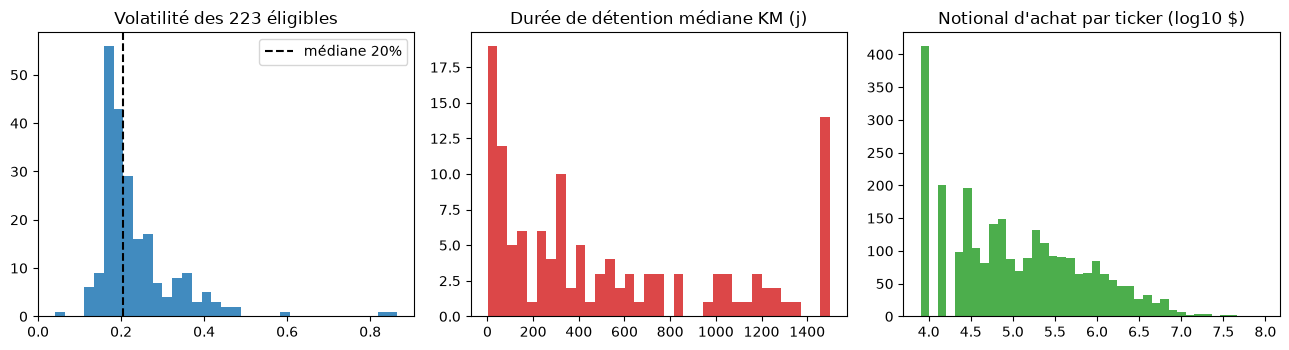

Les tables sont prêtes : membres.csv / tickers.csv / membres_annees.csv + dictionnaire_colonnes.csv


In [40]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
_e = M[M.eligible]
ax[0].hist(_e["vol"].dropna().clip(upper=1.0), bins=35, color="tab:blue", alpha=.85)
ax[0].axvline(float(_e["vol"].median()), color="k", ls="--", label=f"médiane {_e['vol'].median():.0%}")
ax[0].set_title("Volatilité des 223 éligibles"); ax[0].legend()
ax[1].hist(M["duree_km_med"].dropna().clip(upper=1500), bins=35, color="tab:red", alpha=.85)
ax[1].set_title("Durée de détention médiane KM (j)")
ax[2].hist(np.log10(K["notional_buy"].dropna().clip(lower=1)), bins=40, color="tab:green", alpha=.85)
ax[2].set_title("Notional d'achat par ticker (log10 $)")
plt.tight_layout(); plt.show()
print("Les tables sont prêtes : membres.csv / tickers.csv / membres_annees.csv + dictionnaire_colonnes.csv")